**Automated Detection and Classification of Plant Diseases from Leaf Images Using Deep Learning**


**1- Import Required Libraries**

In [ ]:
import os
import random
import shutil
import numpy as np
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report
from google.colab import files
from sklearn.metrics import confusion_matrix

from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

**2- Dataset Paths , Copy & Filter Saudi-Relevant Classes**

In [ ]:
import kagglehub

# Download dataset
base_dataset = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print("Dataset downloaded to:", base_dataset)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset downloaded to: /kaggle/input/plantvillage-dataset


In [ ]:
# Copy only the 3 Saudi-relevant crop classes (Tomato, Pepper, Potato)
# from all three PlantVillage sources (color, grayscale, segmented) into a new cleaned dataset folder for model training.

BASE_PATH = os.path.join(base_dataset, "plantvillage dataset")
OUTPUT_PATH = "/content/plantvillage_saudi"

os.makedirs(OUTPUT_PATH, exist_ok=True)

# Saudi top 3 crops
saudi_crops = [
    "Tomato",
    "Pepper",
    "Potato"
]

sources = ["color", "grayscale", "segmented"]

print("Copying selected Saudi crops...")

for src in sources:
    src_path = os.path.join(BASE_PATH, src)

    for cls in os.listdir(src_path):
        if any(cls.startswith(crop) for crop in saudi_crops):

            src_cls = os.path.join(src_path, cls)
            dst_cls = os.path.join(OUTPUT_PATH, cls)
            os.makedirs(dst_cls, exist_ok=True)

            for img in os.listdir(src_cls):
                src_img = os.path.join(src_cls, img)
                dst_img = os.path.join(dst_cls, f"{src}_{img}")

                shutil.copy(src_img, dst_img)

print("Copying completed.")


Copying selected Saudi crops...
Copying completed.


**3- Explore Dataset Structure**

In [ ]:
print("Classes used in training:\n")
for cls in sorted(os.listdir(DATASET)):
    print(cls, "->", len(os.listdir(os.path.join(DATASET, cls))), "images")

Classes used in training:

Pepper,_bell___Bacterial_spot -> 2991 images
Pepper,_bell___healthy -> 4434 images
Potato___Early_blight -> 3000 images
Potato___Late_blight -> 3000 images
Potato___healthy -> 456 images
Tomato___Bacterial_spot -> 6381 images
Tomato___Early_blight -> 3000 images
Tomato___Late_blight -> 5727 images
Tomato___Leaf_Mold -> 2856 images
Tomato___Septoria_leaf_spot -> 5313 images
Tomato___Spider_mites Two-spotted_spider_mite -> 5028 images
Tomato___Target_Spot -> 4212 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus -> 16071 images
Tomato___Tomato_mosaic_virus -> 1119 images
Tomato___healthy -> 4773 images


**4- Define Global Hyperparameters & Configuration**

In [ ]:
DATASET = "/content/plantvillage_saudi"
IMG_SIZE = 224
BATCH_SIZE = 64
EPOCHS = 15

**5- Split and Load Dataset into Train / Validation / Test**

In [ ]:
# Split the dataset into Train (70%), Validation (15%), and Test (15%)

SOURCE = "/content/plantvillage_saudi"
TARGET = "/content/plantvillage_saudi_split"

splits = ["train", "val", "test"]
ratios = {"train": 0.7, "val": 0.15, "test": 0.15}

# Create folders
for split in splits:
    os.makedirs(os.path.join(TARGET, split), exist_ok=True)

# Loop over each class
for cls in os.listdir(SOURCE):
    cls_path = os.path.join(SOURCE, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    n = len(images)
    train_end = int(n * ratios["train"])
    val_end = train_end + int(n * ratios["val"])

    for split, start, end in [
        ("train", 0, train_end),
        ("val", train_end, val_end),
        ("test", val_end, n)
    ]:
        split_dir = os.path.join(TARGET, split, cls)
        os.makedirs(split_dir, exist_ok=True)
        for img in images[start:end]:
            shutil.copy(os.path.join(cls_path, img), os.path.join(split_dir, img))

print("Dataset successfully split into Train / Val / Test!")

Dataset successfully split into Train / Val / Test!


**6- Define ImageDataGenerators (Data Augmentation)**

In [ ]:
# Create data generators:
# - Training generator applies augmentation to improve generalization.
# - Validation and Test generators only rescale images (no augmentation)

train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    shear_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Load training set with augmentation
test_val_datagen = ImageDataGenerator(rescale=1/255)

train = train_datagen.flow_from_directory(
    "/content/plantvillage_saudi_split/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

# Load validation set (no augmentation)
val = test_val_datagen.flow_from_directory(
    "/content/plantvillage_saudi_split/val",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# Load test set (no augmentation) for final evaluation
test = test_val_datagen.flow_from_directory(
    "/content/plantvillage_saudi_split/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 47847 images belonging to 15 classes.
Found 10248 images belonging to 15 classes.
Found 10266 images belonging to 15 classes.


**- Compute Class Weights to Handle Dataset Imbalance**

In [ ]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train.classes),
    y=train.classes
)

class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(1.5240324892498807),
 1: np.float64(1.027972929423139),
 2: np.float64(1.518952380952381),
 3: np.float64(1.518952380952381),
 4: np.float64(9.999373040752351),
 5: np.float64(0.7142409314823108),
 6: np.float64(1.518952380952381),
 7: np.float64(0.7958582834331337),
 8: np.float64(1.5956978489244622),
 9: np.float64(0.857703683785964),
 10: np.float64(0.9064506962205172),
 11: np.float64(1.08202170963365),
 12: np.float64(0.2835629833763001),
 13: np.float64(4.073818646232439),
 14: np.float64(0.9547440885962287)}

7- Build MobileNetV2 Base Model (Feature Extractor) and Train  (Stage 1 - Frozen Base)

In [ ]:
# Load MobileNetV2 (used as a feature extractor)
# include_top=False removes the final classification layers
# All base layers are initially frozen to prevent destroying pretrained features.
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze most layers
for layer in base_model.layers:
    layer.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**8- Custom Classification Head**

In [ ]:
# Get class names from the training generator
class_names = list(train.class_indices.keys())

# Number of classes
NUM_CLASSES = len(class_names)

print("Number of classes:", NUM_CLASSES)
print("Classes:", class_names)

Number of classes: 15
Classes: ['Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']


In [ ]:
# Build the custom classification head on top of MobileNetV2:

x = base_model.output
x = GlobalAveragePooling2D()(x) # - GlobalAveragePooling2D reduces feature maps into a single vector.
x = Dense(256, activation="relu")(x) # - Dense(256) adds a fully connected layer for learning high-level patterns.
x = Dropout(0.5)(x) # - Dropout(0.5) prevents overfitting.
output = Dense(NUM_CLASSES, activation="softmax")(x) # - Final Dense(NUM_CLASSES, softmax) outputs class probabilities.

model = Model(inputs=base_model.input, outputs=output)

**9- Compile the Model (Stage 1)**

In [ ]:
# Compile the model:

model.compile(
    optimizer=Adam(learning_rate=1e-4),  # - Adam optimizer with a small learning rate (1e-4) helps stable training.
    loss="categorical_crossentropy", # - Categorical cross-entropy is used for multi-class classification.
    metrics=["accuracy"] # - Accuracy is the primary evaluation metric.
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,589,775 (9.88 MB)

 Trainable params: 331,791 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
len(base_model.layers)

154

**10- Unfreeze Last 30 Layers (Fine-Tuning Stage)**

In [ ]:
# Unfreeze the last 30 layers of MobileNetV2 to enable fine-tuning.
# This allows the model to adjust deeper feature representations on our dataset
# while keeping earlier layers stable.

for layer in base_model.layers[-30:]:
    layer.trainable = True

**11- Recompile the Model (Low LR for Fine-Tuning)**

In [ ]:
# Re-compile the model for fine-tuning:
# - Weight decay (1e-5) adds L2 regularization to reduce overfitting.
# - Same loss (categorical crossentropy) and accuracy metric.

model.compile(
    optimizer=Adam(learning_rate=1e-5 , weight_decay=1e-5),  # smaller LR for fine-tuning
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

**12- Define Training Callbacks (ModelCheckpoint & EarlyStopping)**

In [ ]:
# Callbacks:

# ModelCheckpoint saves the model with the best validation accuracy.
checkpoint = ModelCheckpoint(
    "best_mobilenet_saudi.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
# EarlyStopping stops training if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,  # for 3 epochs and restores the best weights.
    restore_best_weights=True
)

**13- Train the Model (Stage 2 – Fine-Tuning)**

In [ ]:
# Train the model
history = model.fit(
    train,
    validation_data=val,
    epochs=15,
    callbacks=[checkpoint, early_stop],
    class_weight=class_weights
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 810ms/step - accuracy: 0.2149 - loss: 2.4832
Epoch 1: val_accuracy improved from -inf to 0.64754, saving model to best_mobilenet_saudi.h5


748/748 ━━━━━━━━━━━━━━━━━━━━ 684s 861ms/step - accuracy: 0.2151 - loss: 2.4826 - val_accuracy: 0.6475 - val_loss: 1.1698
Epoch 2/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.6356 - loss: 1.1849
Epoch 2: val_accuracy improved from 0.64754 to 0.77693, saving model to best_mobilenet_saudi.h5


748/748 ━━━━━━━━━━━━━━━━━━━━ 591s 790ms/step - accuracy: 0.6356 - loss: 1.1847 - val_accuracy: 0.7769 - val_loss: 0.7087
Epoch 3/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.7371 - loss: 0.8231
Epoch 3: val_accuracy improved from 0.77693 to 0.82426, saving model to best_mobilenet_saudi.h5


748/748 ━━━━━━━━━━━━━━━━━━━━ 591s 790ms/step - accuracy: 0.7371 - loss: 0.8230 - val_accuracy: 0.8243 - val_loss: 0.5375
Epoch 4/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 769ms/step - accuracy: 0.7827 - loss: 0.6684
Epoch 4: val_accuracy improved from 0.82426 to 0.85119, saving model to best_mobilenet_saudi.h5


...

748/748 ━━━━━━━━━━━━━━━━━━━━ 590s 788ms/step - accuracy: 0.8766 - loss: 0.3619 - val_accuracy: 0.8998 - val_loss: 0.2965
Epoch 10/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.8844 - loss: 0.3407
Epoch 10: val_accuracy improved from 0.89979 to 0.90252, saving model to best_mobilenet_saudi.h5


748/748 ━━━━━━━━━━━━━━━━━━━━ 589s 787ms/step - accuracy: 0.8844 - loss: 0.3407 - val_accuracy: 0.9025 - val_loss: 0.2902
Epoch 11/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.8906 - loss: 0.3248
Epoch 11: val_accuracy did not improve from 0.90252
748/748 ━━━━━━━━━━━━━━━━━━━━ 589s 787ms/step - accuracy: 0.8906 - loss: 0.3248 - val_accuracy: 0.9021 - val_loss: 0.2903
Epoch 12/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.8970 - loss: 0.3009
Epoch 12: val_accuracy improved from 0.90252 to 0.90340, saving model to best_mobilenet_saudi.h5


748/748 ━━━━━━━━━━━━━━━━━━━━ 588s 786ms/step - accuracy: 0.8970 - loss: 0.3009 - val_accuracy: 0.9034 - val_loss: 0.2884
Epoch 13/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9042 - loss: 0.2783
Epoch 13: val_accuracy improved from 0.90340 to 0.90730, saving model to best_mobilenet_saudi.h5


748/748 ━━━━━━━━━━━━━━━━━━━━ 588s 787ms/step - accuracy: 0.9042 - loss: 0.2783 - val_accuracy: 0.9073 - val_loss: 0.2753
Epoch 14/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9086 - loss: 0.2699
Epoch 14: val_accuracy improved from 0.90730 to 0.91169, saving model to best_mobilenet_saudi.h5


748/748 ━━━━━━━━━━━━━━━━━━━━ 589s 787ms/step - accuracy: 0.9086 - loss: 0.2699 - val_accuracy: 0.9117 - val_loss: 0.2659
Epoch 15/15
748/748 ━━━━━━━━━━━━━━━━━━━━ 0s 771ms/step - accuracy: 0.9169 - loss: 0.2418
Epoch 15: val_accuracy did not improve from 0.91169
748/748 ━━━━━━━━━━━━━━━━━━━━ 590s 789ms/step - accuracy: 0.9169 - loss: 0.2418 - val_accuracy: 0.9101 - val_loss: 0.2683


In [ ]:
model.save("best_mobilenet_saudi.h5")

**14- Evaluate the Model on Test Set**

In [ ]:
print("==== Final Evaluation ====")

# 1. Test Evaluation
test_loss, test_acc = model.evaluate(test)
print("Test Accuracy:", test_acc)

# 2. Validation Evaluation
val_loss, val_accuracy = model.evaluate(val)
print("Validation Accuracy:", val_accuracy)

==== Final Evaluation ====
161/161 ━━━━━━━━━━━━━━━━━━━━ 33s 208ms/step - accuracy: 0.9233 - loss: 0.2305
Test Accuracy: 0.9108708500862122
161/161 ━━━━━━━━━━━━━━━━━━━━ 14s 88ms/step - accuracy: 0.9241 - loss: 0.2272
Validation Accuracy: 0.9116900563240051


**15- Plot Confusion Matrix**

161/161 ━━━━━━━━━━━━━━━━━━━━ 24s 118ms/step


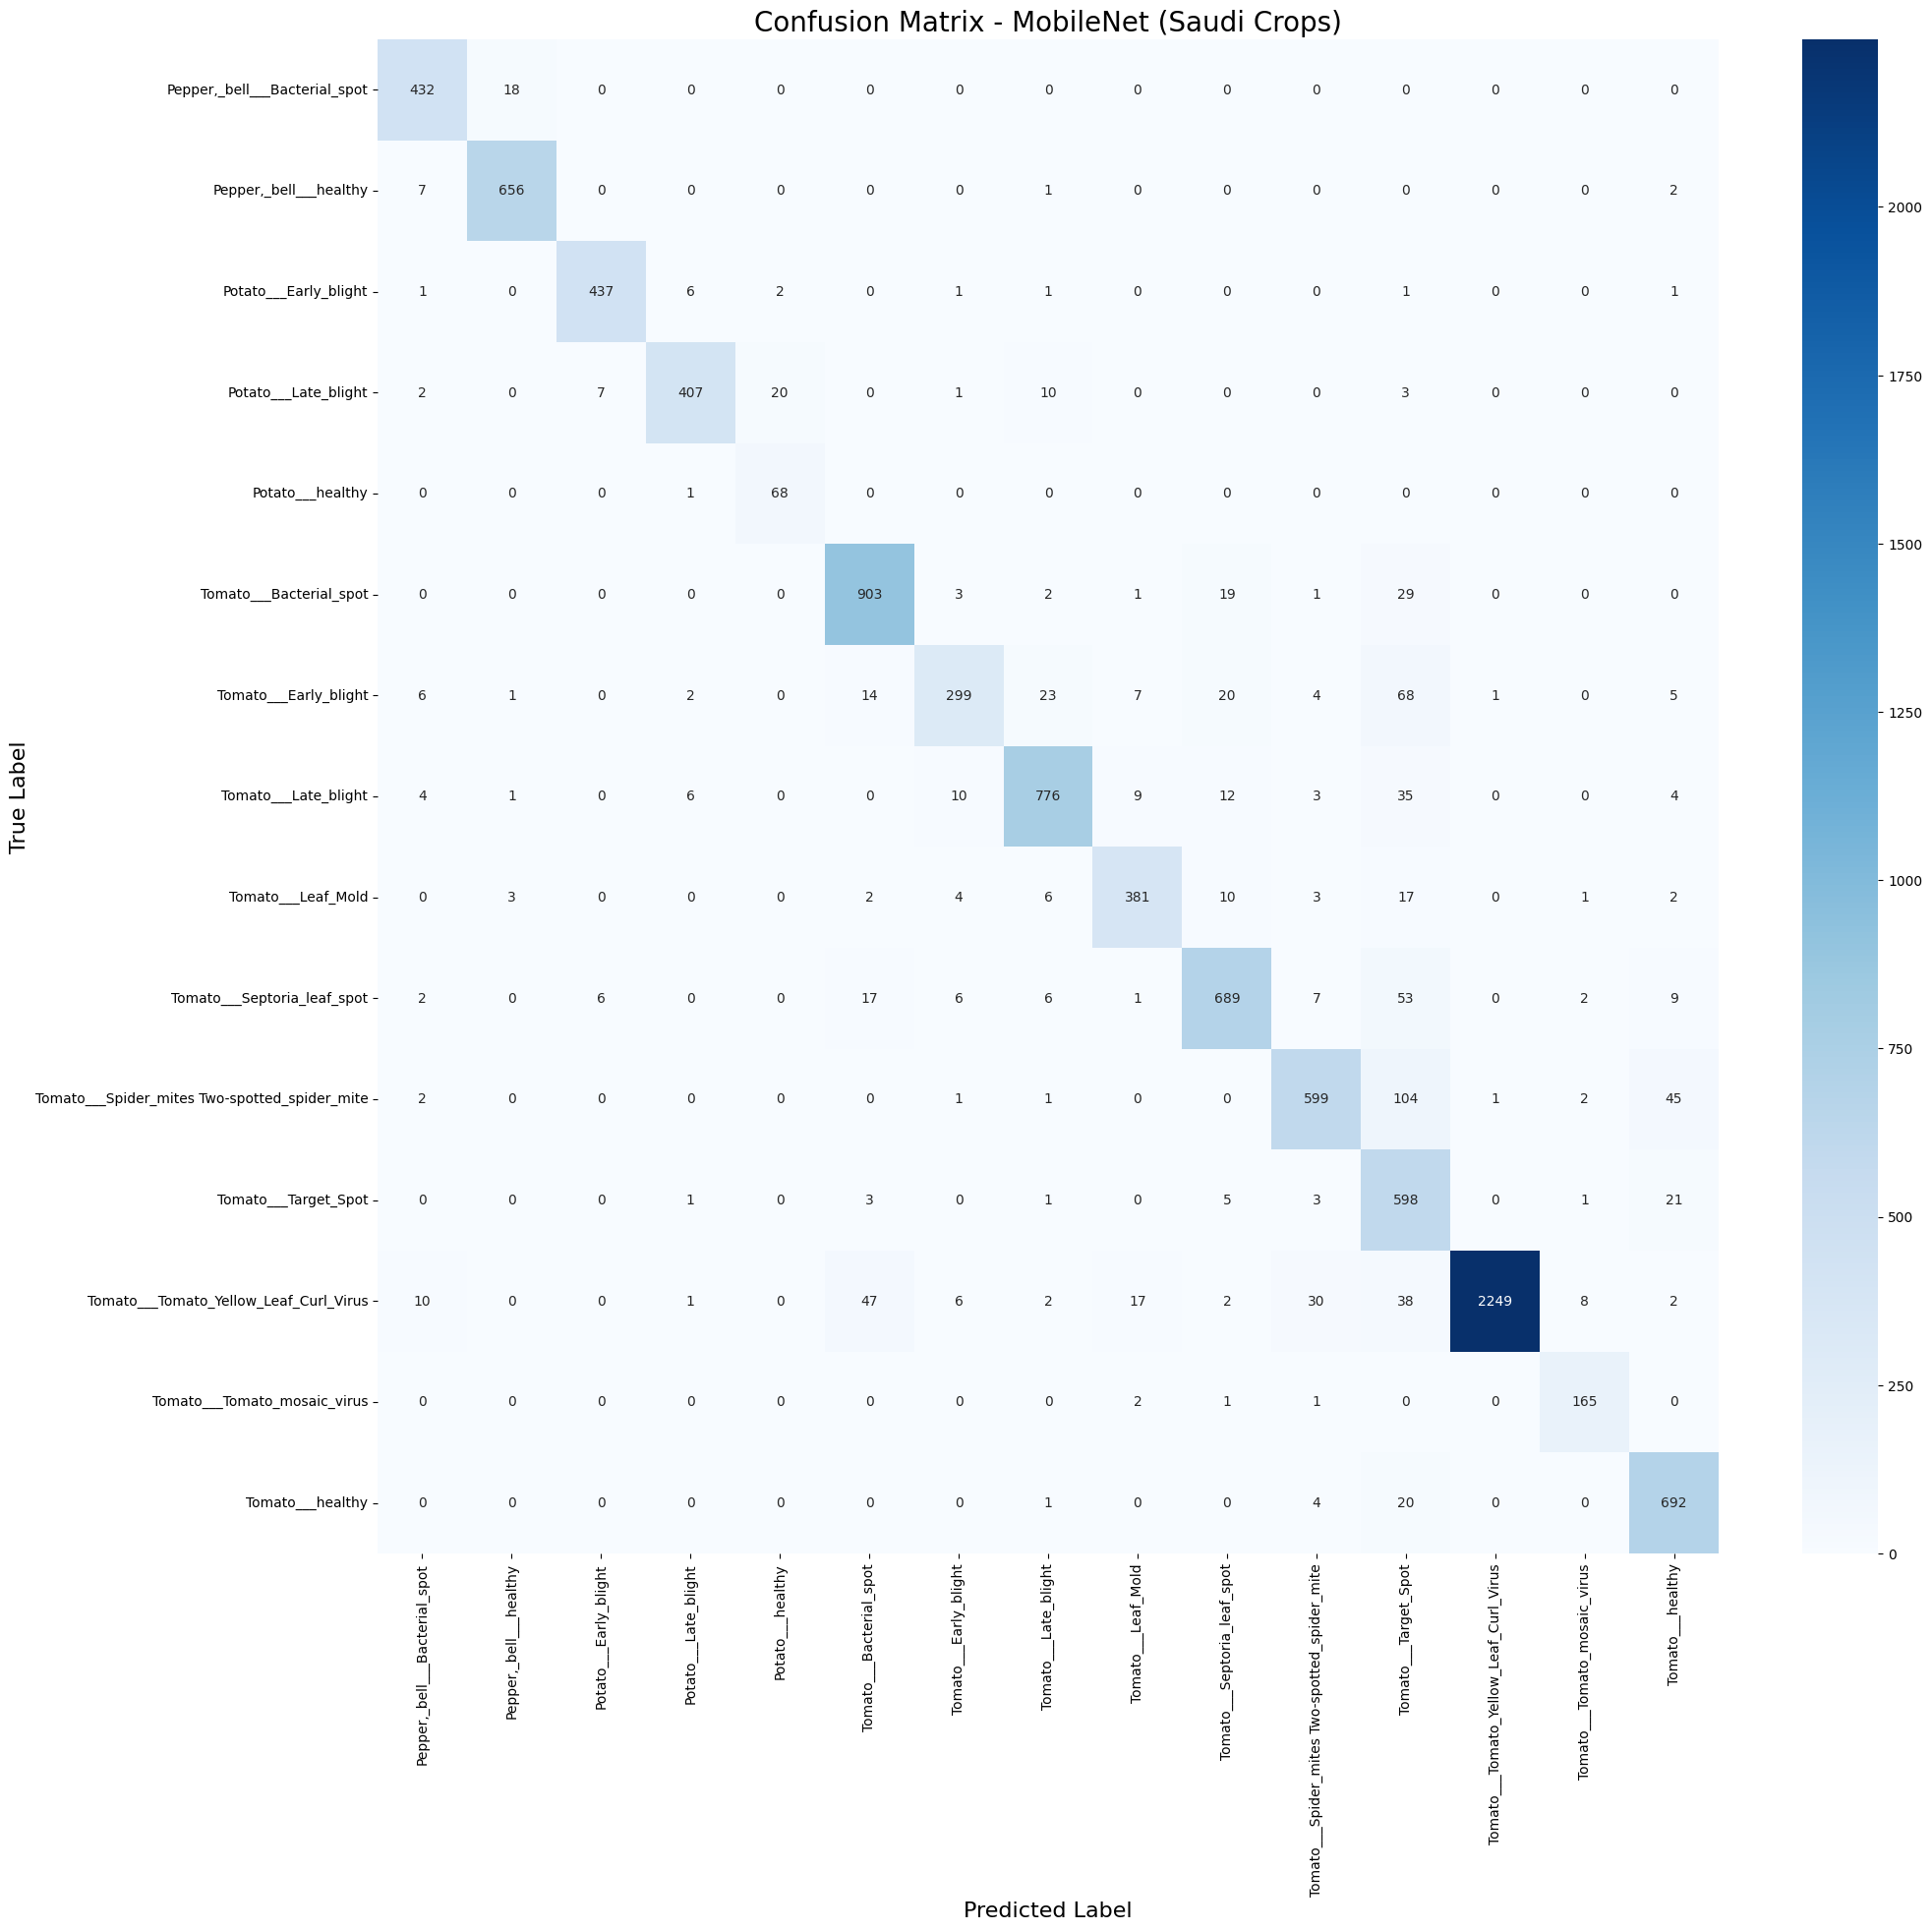

In [ ]:
# True labels (from TEST set)
y_true = test.classes

# Predictions
y_pred = np.argmax(model.predict(test), axis=1)

# Class names in correct order
class_names = list(test.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 20))

sns.heatmap(
    cm,
    cmap="Blues",
    annot=True,
    fmt="d",          # integer format
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - MobileNet (Saudi Crops)", fontsize=20)
plt.xlabel("Predicted Label", fontsize=16)
plt.ylabel("True Label", fontsize=16)

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

**16- Classification Report**

In [ ]:
# Classification report

print(classification_report(y_true, y_pred, target_names=list(test.class_indices.keys())))


                                               precision    recall  f1-score   support

                Pepper,_bell___Bacterial_spot       0.93      0.96      0.94       450
                       Pepper,_bell___healthy       0.97      0.98      0.98       666
                        Potato___Early_blight       0.97      0.97      0.97       450
                         Potato___Late_blight       0.96      0.90      0.93       450
                             Potato___healthy       0.76      0.99      0.86        69
                      Tomato___Bacterial_spot       0.92      0.94      0.93       958
                        Tomato___Early_blight       0.90      0.66      0.77       450
                         Tomato___Late_blight       0.93      0.90      0.92       860
                           Tomato___Leaf_Mold       0.91      0.89      0.90       429
                  Tomato___Septoria_leaf_spot       0.91      0.86      0.89       798
Tomato___Spider_mites Two-spotted_spider_m

**17- Plot Training Accuracy & Loss Curves**

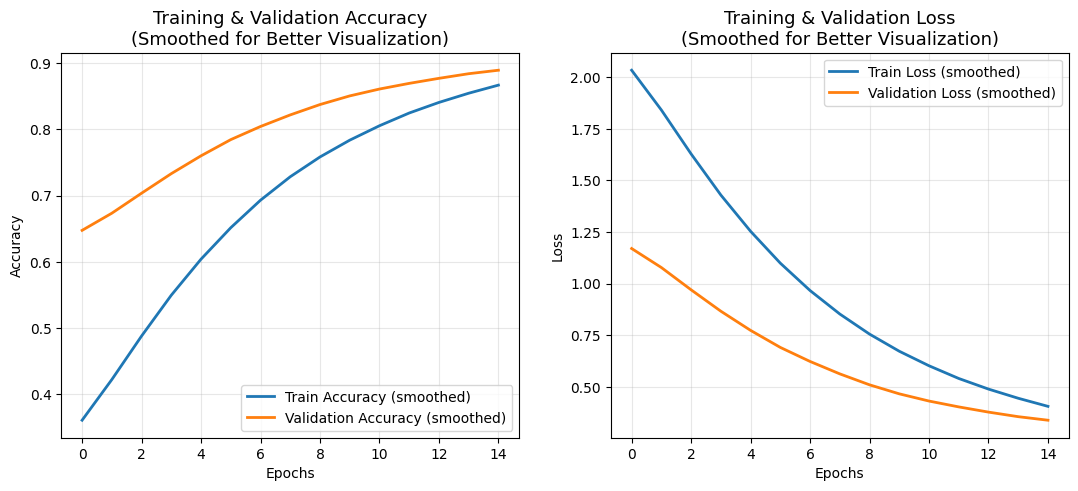

In [ ]:
# Learning Curve
def smooth_curve(points, factor=0.8):
    """Smooths a curve using exponential moving average."""
    smoothed = []
    for p in points:
        if smoothed:
            smoothed.append(smoothed[-1] * factor + p * (1 - factor))
        else:
            smoothed.append(p)
    return smoothed

# Apply smoothing to curves
acc_smooth = smooth_curve(history.history['accuracy'])
val_acc_smooth = smooth_curve(history.history['val_accuracy'])
loss_smooth = smooth_curve(history.history['loss'])
val_loss_smooth = smooth_curve(history.history['val_loss'])

plt.figure(figsize=(13,5))

# ---- Accuracy Curve ----
plt.subplot(1,2,1)
plt.plot(acc_smooth, label='Train Accuracy (smoothed)', linewidth=2)
plt.plot(val_acc_smooth, label='Validation Accuracy (smoothed)', linewidth=2)

plt.title('Training & Validation Accuracy\n(Smoothed for Better Visualization)', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)

# ---- Loss Curve ----
plt.subplot(1,2,2)
plt.plot(loss_smooth, label='Train Loss (smoothed)', linewidth=2)
plt.plot(val_loss_smooth, label='Validation Loss (smoothed)', linewidth=2)

plt.title('Training & Validation Loss\n(Smoothed for Better Visualization)', fontsize=13)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.show()



**18- Predict on New Image**

Loaded classes: 15


Saving Bacterial-spot-symptoms-on-pepper-leaves-for-web.jpg to Bacterial-spot-symptoms-on-pepper-leaves-for-web.jpg

Testing: Bacterial-spot-symptoms-on-pepper-leaves-for-web.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


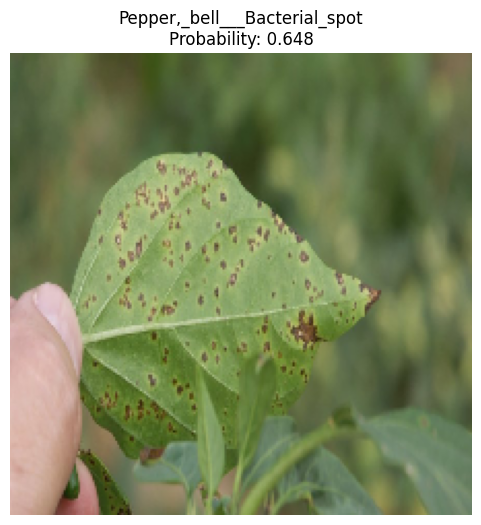

============== RESULT ==============
Predicted Class: Pepper,_bell___Bacterial_spot
Confidence: 0.648


In [ ]:
# Image settings
IMG_SIZE = 224
DATASET = "/content/plantvillage_saudi"   # same folder used during training

# 1) Load the trained model
model = load_model("best_mobilenet_saudi.h5")

# 2) Load class names in the same order used during training
class_names = sorted(os.listdir(DATASET))
print("Loaded classes:", len(class_names))

# 3) Image preprocessing function
def prepare_image(img_path):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)  # shape: (1, 224, 224, 3)
    return img, img_array

# 4) Prediction function
def predict(img_path):
    orig_img, input_data = prepare_image(img_path)
    preds = model.predict(input_data)

    idx = np.argmax(preds[0])
    pred_class = class_names[idx]
    pred_prob = preds[0][idx]

    # Display result
    plt.figure(figsize=(6,6))
    plt.imshow(orig_img)
    plt.axis("off")
    plt.title(f"{pred_class}\nProbability: {pred_prob:.3f}")
    plt.show()

    print("============== RESULT ==============")
    print("Predicted Class:", pred_class)
    print("Confidence:", round(float(pred_prob), 3))
    print("====================================")

# 5) Upload and test
uploaded = files.upload()

for filename in uploaded.keys():
    print("\nTesting:", filename)
    predict(filename)